In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report#, accuracy_score
from sklearn.feature_extraction import DictVectorizer
from sklearn import linear_model

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv")

Here we learn/review some important metrics to assess the quality of a fitted model.

In [3]:
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [5]:
df[df.columns[df.dtypes == 'object']] = df[df.columns[df.dtypes == 'object']].fillna('NA')
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

Let's build the confussion matrix

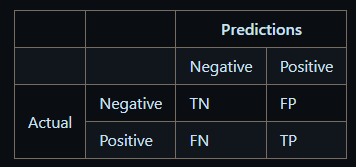

for the logistic regression model fitted in the previous chapter.

In [ ]:
# Dataset splitting
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)

In [8]:
# One-hot encoding
dicts = df_train.drop(['converted'], axis=1).to_dict(orient='records')
dv = DictVectorizer(sparse=False)

train_dict = df_train.to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val.to_dict(orient='records')
X_val = dv.transform(val_dict)

test_dict = df_test.to_dict(orient='records')
X_test = dv.transform(test_dict)

In [10]:
model = linear_model.LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, df_train.converted)
y_pred = model.predict(X_val)

In [21]:
#Build the confussion matrix

# The true positives
TrPos = ((df_val["converted"] == y_pred) & (y_pred > 0.5)).sum()

# The true negatives
TrNeg = ((df_val["converted"] == y_pred) & (y_pred < 0.5)).sum()

# The false positives
FlPos = ((df_val["converted"] != y_pred) & (y_pred > 0.5)).sum()

# The false negatives
FlNeg = ((df_val["converted"] != y_pred) & (y_pred < 0.5)).sum()

# The confussion matrix
CfMat = np.array([[TrNeg, FlPos], [FlNeg, TrPos]])
print(CfMat)

[[ 67  63]
 [  8 155]]


We can also get the confussion matrix from a scikitlearn function.

In [20]:
print(confusion_matrix(df_val['converted'], y_pred))

[[ 67  63]
 [  8 155]]


Among the different metrics of quality of a classification model, there are:

<img src="figs/classification_metrics.png" style="width: 50%; height: auto;">

Notice the definition here is displayed differently from what scikitlearn does. It can be different depending on the library.

In [32]:
print(classification_report(df_val['converted'], y_pred))

              precision    recall  f1-score   support

           0       0.89      0.52      0.65       130
           1       0.71      0.95      0.81       163

    accuracy                           0.76       293
   macro avg       0.80      0.73      0.73       293
weighted avg       0.79      0.76      0.74       293



In [31]:
Rec = TrPos/(TrPos + FlNeg)
Pre = TrPos/(TrPos + FlPos)
F1sc = 2*Rec*Pre/(Rec + Pre)
print(f"Recall: {Rec:.2f}")
print(f"Precision: {Pre:.2f}")
print(f"f1-score: {F1sc:.2f}")

Recall: 0.95
Precision: 0.71
f1-score: 0.81


As we can see, scikitlearn gives us these metrics both for the "0" and "1" events.